Author: Milad Zahmatkesh

This project is about classifying wines from the sklearn wine dataset into their correct class based on their chemical properties.

The data is split into 80% training and 20% test sets, and then scaled using StandardScaler. I tried four different approaches: KNN Classification, Linear SVC, Polynomial SVC, and KNN Regression.

I also ran correlation analysis and PCA to see which features seem to matter most for determining a wine's class. Using just those features, I tested KNN Regression to see if fewer but more relevant columns could still do a good job. After that, I threw in the alcohol column on top of those since I figured alcohol content probably plays a big role in what makes one wine different from another, and ran the experiment again.

One thing I want to note upfront is that the dataset is pretty small only 178 samples. To make up for that, I repeated every experiment 50 times with different random train/test splits so the results wouldn't just depend on one lucky or unlucky split.

The cell below handles all the setup. I import the libraries I'll need throughout the notebook, define a helper class called BestResult that I use to keep track of the best outcomes from each method, and set up a few things like the array of random seeds and the StandardScaler. At the end of the cell, I load the wine dataset and split it into training and test sets.

In [1]:
# import needed libraries common in most cells

from sklearn import datasets

import pandas as pd

import numpy as np

from sklearn.model_selection import train_test_split

from sklearn.metrics import accuracy_score, confusion_matrix

from sklearn.preprocessing import StandardScaler

import matplotlib.pyplot as plt

# Initial Settings

# During experiments, I will save the best results of each method in an array of objects of this class.

class BestResult:

    method: str

    # The best result of each method is almost always 1, so I want to save only the worst and average results.

    isAverage: bool # If isAverage is true, it corresponds to the average; otherwise, it corresponds to the worst.

    successProportionMin: float

    successProportionAvg: float

    confusionMatrix: np.ndarray

        

    def __init__(self, method, isAverage, proportionAvg = 0, proportionMin = 0, confusionMatrix=None):

            self.method = method

            self.isAverage = isAverage

            self.successProportionAvg = proportionAvg

            self.successProportionMin = proportionMin

            self.confusionMatrix = confusionMatrix if confusionMatrix != None else np.zeros((3, 3), dtype=float)

            

    def printResult(self):

        print("Method: " + self.method)

        print(f"Minimum Success Proportion: {self.successProportionMin:.3f}")

        print(f"Average Success Proportion: {self.successProportionAvg:.3f}")

        print("Average of elements in confusion matrix:")

        print(self.confusionMatrix)

        

bestResultsMin = []

bestResultsAvg = []

# In order to test each method, I will create numberOfAttempts groups of train and test data.

numberOfAttempts = 50

# these seed numbers will be used to create random numbers

seed = [42, 25, 31, 75, 76, 16, 10, 93,  9, 44,  8, 55, 86, 19, 11, 

        37, 50, 73, 61, 21,  5, 36, 32, 26, 41, 83, 94, 95, 82, 81, 

        62, 48,  2, 63,  4, 56, 29, 60, 34, 85, 40,  6, 14, 79, 38, 

        87, 74, 91, 43, 98, 68, 28, 51, 59, 49, 66, 47,  1, 65, 80, 

        35, 70, 96, 97,  3, 18, 17, 71, 100, 53, 52, 30, 84, 69, 89, 

        39, 13, 45, 67, 22, 57, 12, 15, 58, 20, 77, 46, 54, 72, 23, 

        27, 33, 88, 92, 99, 64, 24, 78, 90, 7]

# scaler is used to scale values in all columns in a standard range

scaler = StandardScaler()

# Load Data

raw = datasets.load_wine()

wines = pd.DataFrame(raw.data)

wineClass = raw.target

X = wines

y = wineClass

dataGroup = []

for i in range(numberOfAttempts):

    np.random.seed(seed[i])

    # Split data into training and test sets

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

    

    dataGroup.append((X_train, X_test, y_train, y_test))

A quick look at the dataset to understand its shape, data types, and basic statistics.

In [2]:
print("Shape:", wines.shape)
print()
wines.info()
print()
wines.describe()

Shape: (178, 13)

<class 'pandas.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 13 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   0       178 non-null    float64
 1   1       178 non-null    float64
 2   2       178 non-null    float64
 3   3       178 non-null    float64
 4   4       178 non-null    float64
 5   5       178 non-null    float64
 6   6       178 non-null    float64
 7   7       178 non-null    float64
 8   8       178 non-null    float64
 9   9       178 non-null    float64
 10  10      178 non-null    float64
 11  11      178 non-null    float64
 12  12      178 non-null    float64
dtypes: float64(13)
memory usage: 18.2 KB



,0,1,2,3,4,5,6,7,8,9,10,11,12
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258
std,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474
min,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000
25%,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000
50%,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000
75%,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000
max,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000


Here I use a KNN Classifier to try classifying the wines. I tested a bunch of different neighbor counts to see which one gives the best results, and the output shows the accuracy for each along with a bar chart to make it easier to compare.

KNN
Number of neighbors:  3
Min:  0.861
Max:  1.0
Avg:  0.956

Number of neighbors:  5
Min:  0.889
Max:  1.0
Avg:  0.966

Number of neighbors:  7
Min:  0.889
Max:  1.0
Avg:  0.962

Number of neighbors:  10
Min:  0.889
Max:  1.0
Avg:  0.957

Number of neighbors:  11
Min:  0.917
Max:  1.0
Avg:  0.964

Number of neighbors:  12
Min:  0.861
Max:  1.0
Avg:  0.959

Number of neighbors:  13
Min:  0.917
Max:  1.0
Avg:  0.964

Number of neighbors:  14
Min:  0.861
Max:  1.0
Avg:  0.957

Number of neighbors:  17
Min:  0.889
Max:  1.0
Avg:  0.961

Number of neighbors:  24
Min:  0.889
Max:  1.0
Avg:  0.967

Number of neighbors:  25
Min:  0.889
Max:  1.0
Avg:  0.967

Number of neighbors:  26
Min:  0.889
Max:  1.0
Avg:  0.968

Number of neighbors:  27
Min:  0.889
Max:  1.0
Avg:  0.971

Number of neighbors:  28
Min:  0.917
Max:  1.0
Avg:  0.971

Number of neighbors:  30
Min:  0.889
Max:  1.0
Avg:  0.97

Number of neighbors:  40
Min:  0.889
Max:  1.0
Avg:  0.962

Number of neighbors:  50
Min:  0.861
Max

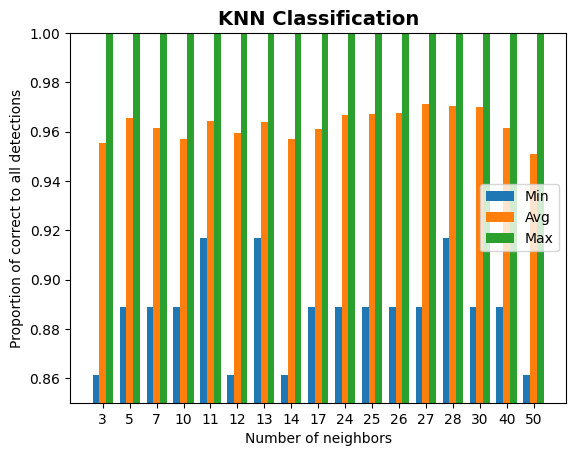

In [3]:
# KNN is used in this cell

from sklearn.neighbors import KNeighborsClassifier

listnNeighbors = [3, 5, 7, 10, 11, 12, 13, 14, 17, 24, 25, 26, 27, 28, 30, 40, 50]

results = []

bestKNNAvg = BestResult("KNN", isAverage = True)

bestKNNMin = BestResult("KNN", isAverage = False)

print("KNN")

for nNeighbors in listnNeighbors:

    print("Number of neighbors: ", nNeighbors)

    scoreList = []

    confusionMatrixList = []

    for i in range(numberOfAttempts):

        # Split data into training and test sets

        X_train, X_test, y_train, y_test = dataGroup[i]

        

        X_train = scaler.fit_transform(X_train)

        X_test = scaler.transform(X_test)

        # Initialize model with determined k

        wineKNN = KNeighborsClassifier(n_neighbors = nNeighbors)

        wineKNN.fit(X_train, y_train)

        y_pred = wineKNN.predict(X_test)

        score = accuracy_score(y_test, y_pred)

        scoreList.append(score)

        confusionMatrixList.append(confusion_matrix(y_test, y_pred))

        # I commented these lines to have a more brief report

        # print("============ ", i+1, " ==============")

        # print("Accuracy score is ", end="")

        # print(round(score, 3))

        # print(confusion_matrix(y_test, y_pred))

        # print("seed: ", seed[i])

        # print()

    minScore = np.min(scoreList)

    maxScore = np.max(scoreList)

    avgScore = np.average(scoreList)

    avgConfusionMatrix = np.average(confusionMatrixList, axis=0)

#     # I commented these lines to have a more brief report

#     print("Confusion Matrix Average:")

#     print(avgConfusionMatrix)

    if (minScore > bestKNNMin.successProportionMin):

        bestKNNMin.successProportionMin = minScore

        bestKNNMin.successProportionAvg = avgScore

        bestKNNMin.method = "KNN k=" + str(nNeighbors)

        bestKNNMin.confusionMatrix = avgConfusionMatrix

    if (avgScore > bestKNNAvg.successProportionAvg):

        bestKNNAvg.successProportionMin = minScore

        bestKNNAvg.successProportionAvg = avgScore

        bestKNNAvg.method = "KNN k=" + str(nNeighbors)

        bestKNNAvg.confusionMatrix = avgConfusionMatrix

    print("Min: ", round(minScore, 3))

    print("Max: ", round(maxScore, 3))

    print("Avg: ", round(avgScore, 3))

    print()

    results.append([minScore, avgScore, maxScore])

print("\nBest minimum result:")

bestKNNMin.printResult()

print("\nBest average result:")

bestKNNAvg.printResult()

bestResultsMin.append(bestKNNMin)

bestResultsAvg.append(bestKNNAvg)

xPlot = np.arange(len(listnNeighbors))

width = 0.25

plt.bar(xPlot - width, [r[0] for r in results], width, label="Min")

plt.bar(xPlot        , [r[1] for r in results], width, label="Avg")

plt.bar(xPlot + width, [r[2] for r in results], width, label="Max")

plt.ylim(0.85, 1)

plt.xticks(xPlot, listnNeighbors)

plt.xlabel("Number of neighbors", fontsize = 10)

plt.ylabel("Proportion of correct to all detections", fontsize = 10)

plt.title("KNN Classification", fontsize = 14, fontweight='bold')

plt.legend(loc='center right')

plt.savefig('KNN.png')

Looking at the results and the plot above, even in the worst case the model still got about 90% of predictions right, which is pretty solid. Some train/test splits actually gave perfect accuracy, and that happened no matter how many neighbors I used. Overall, the number of neighbors doesn't seem to change things too much.

Next I tried a Linear SVC to see how it compares. I tested a few different values of C and printed the results along with a plot.

Linear SVC
C: 1
Min:  0.889
Max:  1.0
Avg:  0.96

C: 3
Min:  0.889
Max:  1.0
Avg:  0.961

C: 5
Min:  0.889
Max:  1.0
Avg:  0.961


Best minimum result:
Method: L. SVC, C=1
Minimum Success Proportion: 0.889
Average Success Proportion: 0.960
Average of elements in confusion matrix:
[[11.84  0.06  0.  ]
 [ 0.38 13.52  0.54]
 [ 0.    0.46  9.2 ]]

Best average result:
Method: L. SVC, C=3
Minimum Success Proportion: 0.889
Average Success Proportion: 0.961
Average of elements in confusion matrix:
[[11.84  0.06  0.  ]
 [ 0.34 13.56  0.54]
 [ 0.    0.46  9.2 ]]


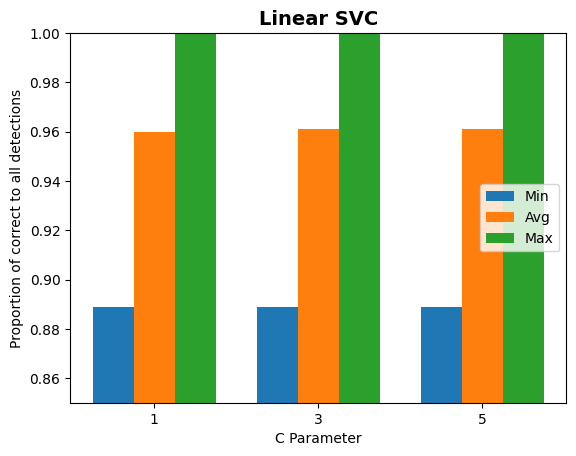

In [4]:
# Linear SVC

from sklearn.svm import SVC

listCLin = [1, 3, 5]

results = []

print("Linear SVC")

bestSVC_LinearAvg = BestResult("L. SVC", isAverage = True)

bestSVC_LinearMin = BestResult("L. SVC", isAverage = False)

for CLin in listCLin:

    print(f"C: {CLin}")

    scoreListLin = []

    confusionMatrixList = []

    for i in range(numberOfAttempts):        

        # Split data into training and test sets

        X_train, X_test, y_train, y_test = dataGroup[i]

        

        X_train = scaler.fit_transform(X_train)

        X_test = scaler.transform(X_test)

        # Initialize and fit a linear SVM.

        svmLinear = SVC(C=CLin, kernel='linear')

        svmLinearWine = svmLinear.fit(X_train, y_train)

        y_pred_lin = svmLinearWine.predict(X_test)

        scoreLin = accuracy_score(y_test, y_pred_lin)

        scoreListLin.append(scoreLin)

        

        confusionMatrixList.append(confusion_matrix(y_test, y_pred_lin))

#         I commented these lines to have a more brief report

#         print("============ ", i+1, " ==============")

#         print("Linear:")

#         print("Accuracy score is ", end="")

#         print(round(scoreLin, 3))

#         print(confusion_matrix(y_test, y_pred_lin))

#         print("seed: ", seed[i])

#         print()

    minScore = np.min(scoreListLin)

    maxScore = np.max(scoreListLin)

    avgScore = np.average(scoreListLin)

    avgConfusionMatrix = np.average(confusionMatrixList, axis=0)

    if (minScore > bestSVC_LinearMin.successProportionMin):

        bestSVC_LinearMin.successProportionMin = minScore

        bestSVC_LinearMin.successProportionAvg = avgScore

        bestSVC_LinearMin.method = "L. SVC, C=" + str(CLin)

        bestSVC_LinearMin.confusionMatrix = avgConfusionMatrix

    if (avgScore > bestSVC_LinearAvg.successProportionAvg):

        bestSVC_LinearAvg.successProportionMin = minScore

        bestSVC_LinearAvg.successProportionAvg = avgScore

        bestSVC_LinearAvg.method = "L. SVC, C=" + str(CLin)

        bestSVC_LinearAvg.confusionMatrix = avgConfusionMatrix

    print("Min: ", round(minScore, 3))

    print("Max: ", round(maxScore, 3))

    print("Avg: ", round(avgScore, 3))

    print()

    results.append([minScore, avgScore, maxScore])

print("\nBest minimum result:")

bestSVC_LinearMin.printResult()

print("\nBest average result:")

bestSVC_LinearAvg.printResult()

bestResultsMin.append(bestSVC_LinearMin)

bestResultsAvg.append(bestSVC_LinearAvg)

xPlot = np.arange(len(listCLin))

width = 0.25

plt.bar(xPlot - width, [r[0] for r in results], width, label="Min")

plt.bar(xPlot        , [r[1] for r in results], width, label="Avg")

plt.bar(xPlot + width, [r[2] for r in results], width, label="Max")

plt.ylim(0.85, 1)

plt.xticks(xPlot, listCLin)

plt.xlabel("C Parameter", fontsize = 10)

plt.ylabel("Proportion of correct to all detections", fontsize = 10)

plt.title("Linear SVC", fontsize = 14, fontweight='bold')

plt.legend(loc='center right')

plt.savefig('LinearSVC.png')



The Linear SVC results turned out to be really similar to KNN  around 90% in the worst case and 100% in the best. One thing I found interesting is that changing the value of C didn't seem to make any difference at all in the output.


Here I switched to Polynomial SVC. I kept C fixed at 10 and tried different polynomial degrees to see which one works best. Results and a plot are shown below.

Polynomial SVC, C = 10, Degree changes
Degree: 2
Min:  0.806
Max:  0.972
Avg:  0.906

Degree: 3
Min:  0.917
Max:  1.0
Avg:  0.954

Degree: 4
Min:  0.75
Max:  0.944
Avg:  0.864

Degree: 5
Min:  0.806
Max:  1.0
Avg:  0.911

Degree: 6
Min:  0.639
Max:  0.889
Avg:  0.799

Degree: 8
Min:  0.5
Max:  0.889
Avg:  0.728

Degree: 10
Min:  0.472
Max:  0.861
Avg:  0.69

Degree: 13
Min:  0.389
Max:  0.861
Avg:  0.658


Best minimum result:
Method: P. SVC C=10 D=3
Minimum Success Proportion: 0.917
Average Success Proportion: 0.954
Average of elements in confusion matrix:
[[11.9   0.    0.  ]
 [ 1.02 13.32  0.1 ]
 [ 0.04  0.5   9.12]]

Best average result:
Method: P. SVC C=10 D=3
Minimum Success Proportion: 0.917
Average Success Proportion: 0.954
Average of elements in confusion matrix:
[[11.9   0.    0.  ]
 [ 1.02 13.32  0.1 ]
 [ 0.04  0.5   9.12]]


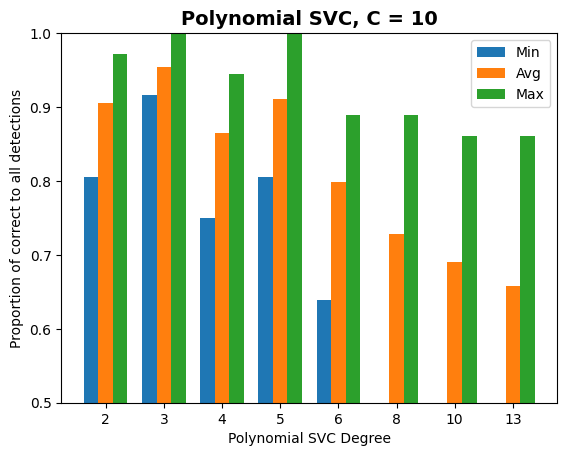

In [5]:
# Polynomial SVC, C=10

from sklearn.svm import SVC

listDegree = [2, 3, 4, 5, 6, 8, 10, 13]

results = []

CPol = 10

print("Polynomial SVC, C = 10, Degree changes")

bestSVC_PloyC10Avg = BestResult("P. SVC - C=10", isAverage = True)

bestSVC_PloyC10Min = BestResult("P. SVC - C=10", isAverage = False)

for degree in listDegree:

    print(f"Degree: {degree}")

    scoreListPol = []

    confusionMatrixList = []

    for i in range(numberOfAttempts):

        # Split data into training and test sets

        X_train, X_test, y_train, y_test = dataGroup[i]

        X_train = scaler.fit_transform(X_train)

        X_test = scaler.transform(X_test)

        # Initialize and fit a polynomial SVM.

        svmPolynomial = SVC(C=CPol, kernel='poly', degree = degree)

        svmPolynomialWine = svmPolynomial.fit(X_train, y_train) 

        y_pred_pol = svmPolynomialWine.predict(X_test)

        scorePol = accuracy_score(y_test, y_pred_pol)

        scoreListPol.append(scorePol)

        

        confusionMatrixList.append(confusion_matrix(y_test, y_pred_pol))

#         I commented these lines to have a more brief report

#         print("============ ", i+1, " ==============")

#         print(f"Polynomial {degree} - C= {CPol}:")

#         print("Accuracy score is ", end="")

#         print(round(scorePol, 3))

#         print(confusion_matrix(y_test, y_pred_pol))

#         print("seed: ", seed[i])

#         print()

    minScore = np.min(scoreListPol)

    maxScore = np.max(scoreListPol)

    avgScore = np.average(scoreListPol)

    avgConfusionMatrix = np.average(confusionMatrixList, axis=0)

    if (minScore > bestSVC_PloyC10Min.successProportionMin):

        bestSVC_PloyC10Min.successProportionMin = minScore

        bestSVC_PloyC10Min.successProportionAvg = avgScore

        bestSVC_PloyC10Min.method = "P. SVC C=10 D=" + str(degree)

        bestSVC_PloyC10Min.confusionMatrix = avgConfusionMatrix

    if (avgScore > bestSVC_PloyC10Avg.successProportionAvg):

        bestSVC_PloyC10Avg.successProportionMin = minScore

        bestSVC_PloyC10Avg.successProportionAvg = avgScore

        bestSVC_PloyC10Avg.method = "P. SVC C=10 D=" + str(degree)

        bestSVC_PloyC10Avg.confusionMatrix = avgConfusionMatrix

    print("Min: ", round(minScore, 3))

    print("Max: ", round(maxScore, 3))

    print("Avg: ", round(avgScore, 3))

    print()

    results.append([minScore, avgScore, maxScore])

print("\nBest minimum result:")

bestSVC_PloyC10Min.printResult()

print("\nBest average result:")

bestSVC_PloyC10Avg.printResult()

bestResultsMin.append(bestSVC_PloyC10Min)

bestResultsAvg.append(bestSVC_PloyC10Avg)

xPlot = np.arange(len(listDegree))

width = 0.25

plt.bar(xPlot - width, [r[0] for r in results], width, label="Min")

plt.bar(xPlot        , [r[1] for r in results], width, label="Avg")

plt.bar(xPlot + width, [r[2] for r in results], width, label="Max")

plt.ylim(0.5, 1)

plt.xticks(xPlot, listDegree)

plt.xlabel("Polynomial SVC Degree", fontsize = 10)

plt.ylabel("Proportion of correct to all detections", fontsize = 10)

plt.title("Polynomial SVC, C = 10", fontsize = 14, fontweight='bold')

plt.legend(loc='upper right')

plt.savefig('PolynomialSVCC10.png')

From the results above, Polynomial SVC generally performed worse than both Linear SVC and KNN regardless of what degree I used. The one exception was degree 3, which came close to matching the earlier methods. Other than that, higher degrees just made things worse.

Since degree 3 was clearly the best, I locked that in and started experimenting with different values of C to see if I could squeeze out any better performance. Results and plot are below

Polynomial SVC, Degree = 3, C changes
Polynomial C: 0.5
Min:  0.778
Max:  1.0
Avg:  0.911

Polynomial C: 1
Min:  0.861
Max:  1.0
Avg:  0.948

Polynomial C: 2
Min:  0.861
Max:  1.0
Avg:  0.958

Polynomial C: 3
Min:  0.889
Max:  1.0
Avg:  0.96

Polynomial C: 4
Min:  0.889
Max:  1.0
Avg:  0.954

Polynomial C: 5
Min:  0.917
Max:  1.0
Avg:  0.956

Polynomial C: 7
Min:  0.917
Max:  1.0
Avg:  0.954

Polynomial C: 10
Min:  0.917
Max:  1.0
Avg:  0.954


Best minimum result:
Method: P. SVC D=3 C=5
Minimum Success Proportion: 0.917
Average Success Proportion: 0.956
Average of elements in confusion matrix:
[[11.9   0.    0.  ]
 [ 0.94 13.4   0.1 ]
 [ 0.02  0.52  9.12]]

Best average result:
Method: P. SVC D=3 C=3
Minimum Success Proportion: 0.889
Average Success Proportion: 0.960
Average of elements in confusion matrix:
[[11.84  0.06  0.  ]
 [ 0.74 13.6   0.1 ]
 [ 0.    0.54  9.12]]


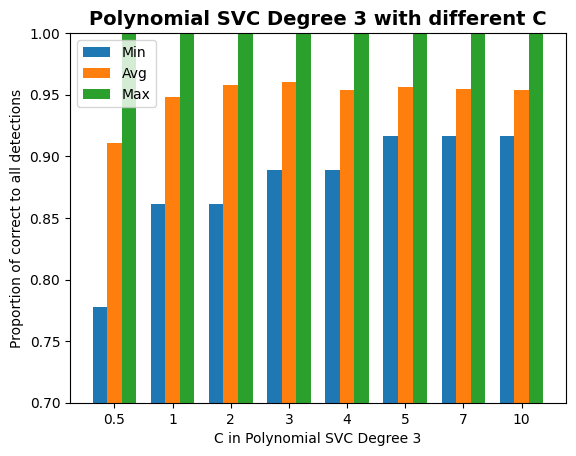

In [6]:
# Polynomial SVC, Degree 3
from sklearn.svm import SVC

listCPol = [0.5, 1, 2, 3, 4, 5, 7, 10]

results = []

print("Polynomial SVC, Degree = 3, C changes")

bestSVC_PloyD3g3Avg = BestResult("P. SVC - Degree = 3", isAverage = True)
bestSVC_PloyD3g3Min = BestResult("P. SVC - Degree = 3", isAverage = False)

for CPoly in listCPol:
    print(f"Polynomial C: {CPoly}")
    scoreListPol = []
    confusionMatrixList = []
    for i in range(numberOfAttempts):        
        # Split data into training and test sets
        X_train, X_test, y_train, y_test = dataGroup[i]

        X_train = scaler.fit_transform(X_train)
        X_test = scaler.transform(X_test)

        # Initialize and fit a degree 3 polynomial SVM.
        svmPolynomial = SVC(C=CPoly, kernel='poly', degree= 3)

        svmPolynomialWine = svmPolynomial.fit(X_train, y_train) 

        y_pred_pol = svmPolynomialWine.predict(X_test)

        scorePol = accuracy_score(y_test, y_pred_pol)
        scoreListPol.append(scorePol)
        
        confusionMatrixList.append(confusion_matrix(y_test, y_pred_pol))

#         I commented these lines to have a more brief report
#         print("============ ", i+1, " ==============")
#         print("Polynomial 3:")
#         print("Accuracy score is ", end="")
#         print(round(scorePol, 3))
#         print(confusion_matrix(y_test, y_pred_pol))

#         print("seed: ", seed[i])
#         print()

    minScore = np.min(scoreListPol)
    maxScore = np.max(scoreListPol)
    avgScore = np.average(scoreListPol)
    avgConfusionMatrix = np.average(confusionMatrixList, axis=0)

    if (minScore > bestSVC_PloyD3g3Min.successProportionMin):
        bestSVC_PloyD3g3Min.successProportionMin = minScore
        bestSVC_PloyD3g3Min.successProportionAvg = avgScore
        bestSVC_PloyD3g3Min.method = "P. SVC D=3 C=" + str(CPoly)
        bestSVC_PloyD3g3Min.confusionMatrix = avgConfusionMatrix

    if (avgScore > bestSVC_PloyD3g3Avg.successProportionAvg):
        bestSVC_PloyD3g3Avg.successProportionMin = minScore
        bestSVC_PloyD3g3Avg.successProportionAvg = avgScore
        bestSVC_PloyD3g3Avg.method = "P. SVC D=3 C=" + str(CPoly)
        bestSVC_PloyD3g3Avg.confusionMatrix = avgConfusionMatrix

    print("Min: ", round(minScore, 3))
    print("Max: ", round(maxScore, 3))
    print("Avg: ", round(avgScore, 3))
    print()

    results.append([minScore, avgScore, maxScore])

print("\nBest minimum result:")
bestSVC_PloyD3g3Min.printResult()
print("\nBest average result:")
bestSVC_PloyD3g3Avg.printResult()

bestResultsMin.append(bestSVC_PloyD3g3Min)
bestResultsAvg.append(bestSVC_PloyD3g3Avg)

xPlot = np.arange(len(listCPol))
width = 0.25

plt.bar(xPlot - width, [r[0] for r in results], width, label="Min")
plt.bar(xPlot        , [r[1] for r in results], width, label="Avg")
plt.bar(xPlot + width, [r[2] for r in results], width, label="Max")
plt.ylim(0.7, 1)
plt.xticks(xPlot, listCPol)

plt.xlabel("C in Polynomial SVC Degree 3", fontsize = 10)
plt.ylabel("Proportion of correct to all detections", fontsize = 10)
plt.title("Polynomial SVC Degree 3 with different C", fontsize = 14, fontweight='bold')
plt.legend(loc='upper left')
plt.savefig('PolynomialSVCDegree3CChanges.png')

The plot shows that once C gets above about 2, the results stop changing. So basically, Polynomial SVC with the right settings ends up performing about the same as Linear SVC — it doesn't really add anything.

This one is a bit unconventional. I used a KNN Regressor, which normally outputs continuous values, but I rounded the predictions to the nearest integer to turn it into a classifier. I was curious to see if this approach could hold up against the actual classification methods. I tried different neighbor counts and the results are shown below.

KNN Regression
Number of neighbors:  3
Min:  0.861
Max:  1.0
Avg:  0.956

Number of neighbors:  5
Min:  0.889
Max:  1.0
Avg:  0.966

Number of neighbors:  7
Min:  0.889
Max:  1.0
Avg:  0.963

Number of neighbors:  9
Min:  0.889
Max:  1.0
Avg:  0.965

Number of neighbors:  10
Min:  0.861
Max:  1.0
Avg:  0.957

Number of neighbors:  11
Min:  0.917
Max:  1.0
Avg:  0.969

Number of neighbors:  12
Min:  0.889
Max:  1.0
Avg:  0.962

Number of neighbors:  13
Min:  0.917
Max:  1.0
Avg:  0.97

Number of neighbors:  14
Min:  0.889
Max:  1.0
Avg:  0.963

Number of neighbors:  15
Min:  0.889
Max:  1.0
Avg:  0.967

Number of neighbors:  20
Min:  0.889
Max:  1.0
Avg:  0.961

Number of neighbors:  27
Min:  0.917
Max:  1.0
Avg:  0.968

Number of neighbors:  30
Min:  0.889
Max:  1.0
Avg:  0.961


Best minimum result:
Method: KNN R., k=11
Minimum Success Proportion: 0.917
Average Success Proportion: 0.969
Average of elements in confusion matrix:
[[11.88  0.02  0.  ]
 [ 0.78 13.36  0.3 ]
 [ 0.    0.    9

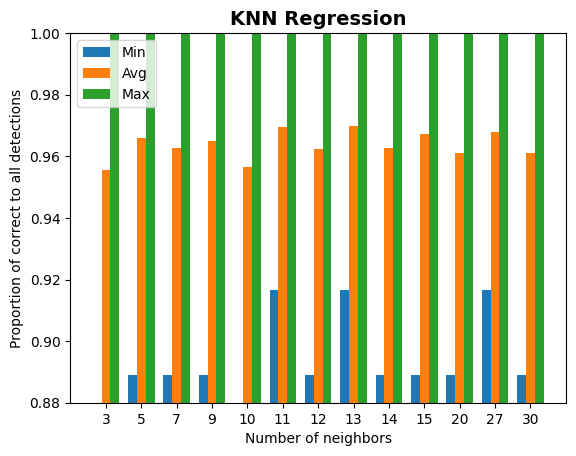

In [7]:
# KNN Regression

from sklearn.neighbors import KNeighborsRegressor

listnNeighbors = [3, 5, 7, 9, 10, 11, 12, 13, 14, 15, 20, 27, 30]

results = []

print("KNN Regression")

bestKNNRegressionAvg = BestResult("KNN Regression", isAverage = True)

bestKNNRegressionMin = BestResult("KNN Regression", isAverage = False)

for nNeighbors in listnNeighbors:

    scoreList = []

    print("Number of neighbors: ", nNeighbors)

    confusionMatrixList = []

    for i in range(numberOfAttempts):

        # Split data into training and test sets

        X_train, X_test, y_train, y_test = dataGroup[i]

        X_train = scaler.fit_transform(X_train)

        X_test = scaler.transform(X_test)

        # Initialize and fit a KNN regressor

        KNN = KNeighborsRegressor(n_neighbors = nNeighbors)

        KNN.fit(X_train, y_train)

        # Compute predicted value

        y_pred = KNN.predict(X_test)

        

        # Round to nearest integer because we need class numbers (decimal places are meaningless)

        y_pred_round = [round(item, 0) for item in y_pred]

        score = accuracy_score(y_test, y_pred_round)

        scoreList.append(score)

        

        confusionMatrixList.append(confusion_matrix(y_test, y_pred_round))

#         I commented these lines to have a more brief report

#         print("============ ", i+1, " ==============")

#         print("Accuracy score is ", end="")

#         print(round(score, 3))

#         print(confusion_matrix(y_test, y_pred_round))

#         print("seed: ", seed[i])

#         print()

    minScore = np.min(scoreList)

    maxScore = np.max(scoreList)

    avgScore = np.average(scoreList)

    avgConfusionMatrix = np.average(confusionMatrixList, axis=0)

    if (minScore > bestKNNRegressionMin.successProportionMin):

        bestKNNRegressionMin.successProportionMin = minScore

        bestKNNRegressionMin.successProportionAvg = avgScore

        bestKNNRegressionMin.method = "KNN R., k=" + str(nNeighbors)

        bestKNNRegressionMin.confusionMatrix = avgConfusionMatrix

    if (avgScore > bestKNNRegressionAvg.successProportionAvg):

        bestKNNRegressionAvg.successProportionMin = minScore

        bestKNNRegressionAvg.successProportionAvg = avgScore

        bestKNNRegressionAvg.method = "KNN R., k=" + str(nNeighbors)

        bestKNNRegressionAvg.confusionMatrix = avgConfusionMatrix

    print("Min: ", round(minScore, 3))

    print("Max: ", round(maxScore, 3))

    print("Avg: ", round(avgScore, 3))

    print()

    results.append([minScore, avgScore, maxScore])

print("\nBest minimum result:")

bestKNNRegressionMin.printResult()

print("\nBest average result:")

bestKNNRegressionAvg.printResult()

bestResultsMin.append(bestKNNRegressionMin)

bestResultsAvg.append(bestKNNRegressionAvg)

xPlot = np.arange(len(listnNeighbors))

width = 0.25

plt.bar(xPlot - width, [r[0] for r in results], width, label="Min")

plt.bar(xPlot        , [r[1] for r in results], width, label="Avg")

plt.bar(xPlot + width, [r[2] for r in results], width, label="Max")

plt.ylim(0.88, 1)

plt.xticks(xPlot, listnNeighbors)

plt.xlabel("Number of neighbors", fontsize = 10)

plt.ylabel("Proportion of correct to all detections", fontsize = 10)

plt.title("KNN Regression", fontsize = 14, fontweight='bold')

plt.legend(loc='upper left')

plt.savefig('KNN_Regression.png')



This actually surprised me KNN Regression performed just as well as regular KNN, and in some ways even better. The best average accuracy here came from using 13 neighbors, which feels more reasonable than the 27 neighbors that KNN needed to hit its best result.

Even though the results so far have been pretty good, I wanted to see if I could do better by cutting out features that might not matter much for classification. I ran a correlation analysis to figure out which columns seem most relevant, then used PCA to plot the classes and get a visual sense of the separation. After that, I tested the idea using KNN Regression on just those selected columns.

Correlation Matrix:
       0      1      2      3      4      5      6      7      8      9   \
0   1.000  0.094  0.212 -0.310  0.271  0.289  0.237 -0.156  0.137  0.546   
1   0.094  1.000  0.164  0.289 -0.055 -0.335 -0.411  0.293 -0.221  0.249   
2   0.212  0.164  1.000  0.443  0.287  0.129  0.115  0.186  0.010  0.259   
3  -0.310  0.289  0.443  1.000 -0.083 -0.321 -0.351  0.362 -0.197  0.019   
4   0.271 -0.055  0.287 -0.083  1.000  0.214  0.196 -0.256  0.236  0.200   
5   0.289 -0.335  0.129 -0.321  0.214  1.000  0.865 -0.450  0.612 -0.055   
6   0.237 -0.411  0.115 -0.351  0.196  0.865  1.000 -0.538  0.653 -0.172   
7  -0.156  0.293  0.186  0.362 -0.256 -0.450 -0.538  1.000 -0.366  0.139   
8   0.137 -0.221  0.010 -0.197  0.236  0.612  0.653 -0.366  1.000 -0.025   
9   0.546  0.249  0.259  0.019  0.200 -0.055 -0.172  0.139 -0.025  1.000   
10 -0.072 -0.561 -0.075 -0.274  0.055  0.434  0.543 -0.263  0.296 -0.522   
11  0.072 -0.369  0.004 -0.277  0.066  0.700  0.787 -0.503  0.519 -0

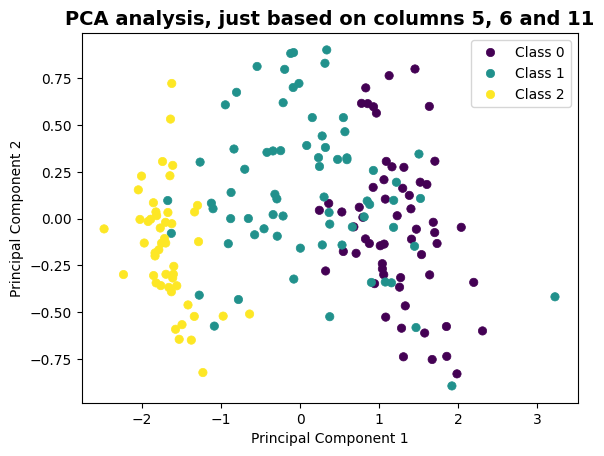

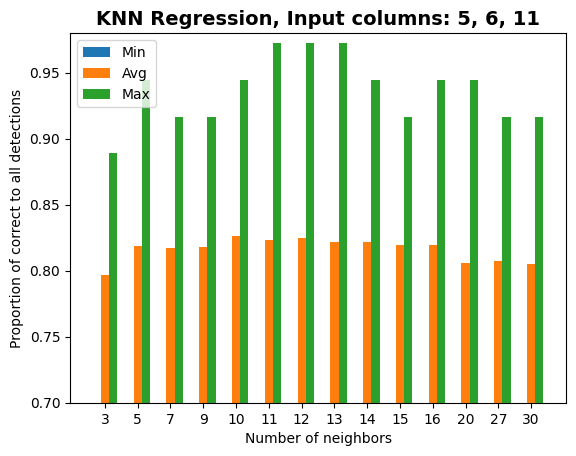

In [8]:
# Correlation test between columns and output
wines[13] = y
print('Correlation Matrix:')
print(round(wines.corr(), 3))
# It can be seen that Columns 6, 11 and 5 have interesting relationship

from sklearn.decomposition import PCA

X = wines[[5, 6, 11]]
y = wineClass

# I use PCA with 2 components to use the result in a plot
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], 
                      c=y, 
                      cmap='viridis',                       
                      linewidth=0.5)

# I hope the plot shows a clear border between wine classes
plt.title('PCA analysis, just based on columns 5, 6 and 11', fontsize=14, fontweight='bold')

legend_labels = ['Class 0', 'Class 1', 'Class 2']
plt.xlabel("Principal Component 1", fontsize=10)
plt.ylabel("Principal Component 2", fontsize=10)
plt.legend(handles=scatter.legend_elements()[0], 
                     labels=legend_labels,
                     loc='upper right',
                     fontsize=10)
plt.savefig('PCA_Columns_5_6_11.png')
plt.figure()

# Classification using the best found method, KNN Regression  
print("\nKNN Regression for columns 5, 6 and 11")
results = []
listnNeighbors = [3, 5, 7, 9, 10, 11, 12, 13, 14, 15, 16, 20, 27, 30]

bestKNNRegressionClmn5_6_11_Avg = BestResult("KNN R. Clmn 5 6 11", isAverage = True)
bestKNNRegressionClmn5_6_11_Min = BestResult("KNN R. Clmn 5 6 11", isAverage = False)

for nNeighbors in listnNeighbors:
    scoreList = []
    print("Number of neighbors: ", nNeighbors)
    confusionMatrixList = []
    for i in range(numberOfAttempts):
        np.random.seed(seed[i])

        # Split data into training and test sets
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

        X_train = scaler.fit_transform(X_train)
        X_test = scaler.transform(X_test)

        # Initialize and fit a KNN regressor
        KNN = KNeighborsRegressor(n_neighbors = nNeighbors)
        KNN.fit(X_train, y_train)

        # Compute predicted value
        y_pred = KNN.predict(X_test)

        # Round to nearest integer because we need class numbers (decimal places are meaningless)
        y_pred_round = [round(item, 0) for item in y_pred]

        score = accuracy_score(y_test, y_pred_round)
        scoreList.append(score)
        
        confusionMatrixList.append(confusion_matrix(y_test, y_pred_round))

    #         I commented these lines to have a more brief report
    #         print("============ ", i+1, " ==============")
    #         print("Accuracy score is ", end="")
    #         print(round(score, 3))
    #         print(confusion_matrix(y_test, y_pred_round))

    #         print("seed: ", seed[i])
    #         print()

    minScore = np.min(scoreList)
    maxScore = np.max(scoreList)
    avgScore = np.average(scoreList)
    avgConfusionMatrix = np.average(confusionMatrixList, axis=0)
    
    if (minScore > bestKNNRegressionClmn5_6_11_Min.successProportionMin):
        bestKNNRegressionClmn5_6_11_Min.successProportionMin = minScore
        bestKNNRegressionClmn5_6_11_Min.successProportionAvg = avgScore
        bestKNNRegressionClmn5_6_11_Min.method = "Best Corr. K=" + str(nNeighbors)
        bestKNNRegressionClmn5_6_11_Min.confusionMatrix = avgConfusionMatrix

    if (avgScore > bestKNNRegressionClmn5_6_11_Avg.successProportionAvg):
        bestKNNRegressionClmn5_6_11_Avg.successProportionMin = minScore
        bestKNNRegressionClmn5_6_11_Avg.successProportionAvg = avgScore
        bestKNNRegressionClmn5_6_11_Avg.method = "Best Corr. K=" + str(nNeighbors)
        bestKNNRegressionClmn5_6_11_Avg.confusionMatrix = avgConfusionMatrix

    print("Min: ", round(minScore, 3))
    print("Max: ", round(maxScore, 3))
    print("Avg: ", round(avgScore, 3))
    print()
    
    results.append([minScore, avgScore, maxScore])

print("\nBest minimum result:")
bestKNNRegressionClmn5_6_11_Min.printResult()
print("\nBest average result:")
bestKNNRegressionClmn5_6_11_Avg.printResult()

bestResultsMin.append(bestKNNRegressionClmn5_6_11_Min)
bestResultsAvg.append(bestKNNRegressionClmn5_6_11_Avg)

xPlot = np.arange(len(listnNeighbors))
width = 0.25

plt.bar(xPlot - width, [r[0] for r in results], width, label="Min")
plt.bar(xPlot        , [r[1] for r in results], width, label="Avg")
plt.bar(xPlot + width, [r[2] for r in results], width, label="Max")
plt.ylim(0.7, 0.98)
plt.xticks(xPlot, listnNeighbors)
plt.xlabel("Number of neighbors", fontsize = 10)
plt.ylabel("Proportion of correct to all detections", fontsize = 10)
plt.title("KNN Regression, Input columns: 5, 6, 11", fontsize = 14, fontweight='bold')
plt.legend(loc='upper left')
plt.savefig('KNN_Regression5_6_11.png')

The PCA plot showed overlap between class 1 and class 2. This also happens with all features, so I thought KNN Regression might still work with fewer columns. But the results were not good.

I wasn't satisfied with how that turned out, so I decided to add the alcohol column back in on top of the three I already had. My thinking was that alcohol content has to play a significant role in distinguishing wine types, so maybe it would help close the gap. I ran the same KNN Regression setup again with this extra feature included.

Column indices and names:
0: alcohol
1: malic_acid
2: ash
3: alcalinity_of_ash
4: magnesium
5: total_phenols
6: flavanoids
7: nonflavanoid_phenols
8: proanthocyanins
9: color_intensity
10: hue
11: od280/od315_of_diluted_wines
12: proline

KNN Regression for columns 0, 5, 6 and 11
Number of neighbors:  3
Min:  0.833
Max:  1.0
Avg:  0.921

Number of neighbors:  5
Min:  0.806
Max:  1.0
Avg:  0.922

Number of neighbors:  7
Min:  0.806
Max:  1.0
Avg:  0.921

Number of neighbors:  9
Min:  0.806
Max:  1.0
Avg:  0.919

Number of neighbors:  10
Min:  0.778
Max:  1.0
Avg:  0.914

Number of neighbors:  11
Min:  0.806
Max:  1.0
Avg:  0.917

Number of neighbors:  12
Min:  0.806
Max:  1.0
Avg:  0.92

Number of neighbors:  13
Min:  0.806
Max:  1.0
Avg:  0.921

Number of neighbors:  14
Min:  0.778
Max:  1.0
Avg:  0.919

Number of neighbors:  15
Min:  0.778
Max:  1.0
Avg:  0.924

Number of neighbors:  16
Min:  0.806
Max:  1.0
Avg:  0.921

Number of neighbors:  20
Min:  0.806
Max:  1.0
Avg:  0.921

Numb

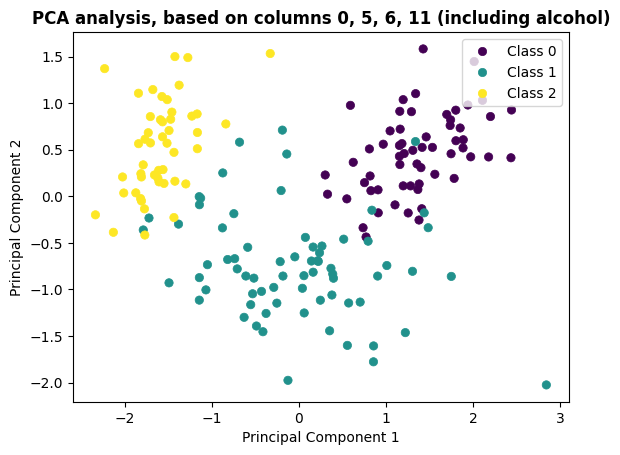

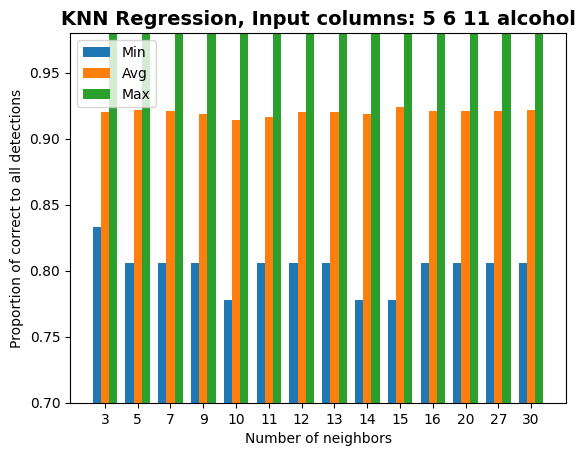

In [9]:
# I use this report to understand which index is related to alcohol
print("Column indices and names:")
for idx, name in enumerate(raw.feature_names):
    print(f"{idx}: {name}")

X = wines[[0, 5, 6, 11]]
y = wineClass

# I use PCA with 2 components to use the result in a plot
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# I hope the plot shows a clear border between wine classes
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], 
                      c=y, 
                      cmap='viridis',                       
                      linewidth=0.5)

plt.title('PCA analysis, based on columns 0, 5, 6, 11 (including alcohol)', fontsize=12, fontweight='bold')

legend_labels = ['Class 0', 'Class 1', 'Class 2']
plt.xlabel("Principal Component 1", fontsize=10)
plt.ylabel("Principal Component 2", fontsize=10)
plt.legend(handles=scatter.legend_elements()[0], 
                     labels=legend_labels,
                     loc='upper right',
                     fontsize=10)
plt.savefig('PCA_Columns_5_6_11_alcohol.png')
plt.figure()
    
results = []
print("\nKNN Regression for columns 0, 5, 6 and 11")
listnNeighbors = [3, 5, 7, 9, 10, 11, 12, 13, 14, 15, 16, 20, 27, 30]

bestKNNRegressionClmn0_5_6_11_Avg = BestResult("KNN R. Alcohol Added", isAverage = True)
bestKNNRegressionClmn0_5_6_11_Min = BestResult("KNN R. Alcohol Added", isAverage = False)

for nNeighbors in listnNeighbors:
    scoreList = []
    print("Number of neighbors: ", nNeighbors)
    confusionMatrixList = []
    for i in range(numberOfAttempts):
        np.random.seed(seed[i])

        # Split data into training and test sets
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

        X_train = scaler.fit_transform(X_train)
        X_test = scaler.transform(X_test)

        # Initialize and fit a KNN regressor
        KNN = KNeighborsRegressor(n_neighbors = nNeighbors)
        KNN.fit(X_train, y_train)

        # Compute predicted value
        y_pred = KNN.predict(X_test)

        # Round to nearest integer because we need class numbers (decimal places are meaningless)
        y_pred_round = [round(item, 0) for item in y_pred]

        score = accuracy_score(y_test, y_pred_round)
        scoreList.append(score)

        confusionMatrixList.append(confusion_matrix(y_test, y_pred_round))
        
    #         I commented these lines to have a more brief report
    #         print("============ ", i+1, " ==============")
    #         print("Accuracy score is ", end="")
    #         print(round(score, 3))
    #         print(confusion_matrix(y_test, y_pred_round))

    #         print("seed: ", seed[i])
    #         print()

    minScore = np.min(scoreList)
    maxScore = np.max(scoreList)
    avgScore = np.average(scoreList)
    avgConfusionMatrix = np.average(confusionMatrixList, axis=0)
    
    if (minScore > bestKNNRegressionClmn0_5_6_11_Min.successProportionMin):
        bestKNNRegressionClmn0_5_6_11_Min.successProportionMin = minScore
        bestKNNRegressionClmn0_5_6_11_Min.successProportionAvg = avgScore
        bestKNNRegressionClmn0_5_6_11_Min.method = "5 6 11+Alcohol K=" + str(nNeighbors)
        bestKNNRegressionClmn0_5_6_11_Min.confusionMatrix = avgConfusionMatrix

    if (avgScore > bestKNNRegressionClmn0_5_6_11_Avg.successProportionAvg):
        bestKNNRegressionClmn0_5_6_11_Avg.successProportionMin = minScore
        bestKNNRegressionClmn0_5_6_11_Avg.successProportionAvg = avgScore
        bestKNNRegressionClmn0_5_6_11_Avg.method = "5 6 11+Alcohol K=" + str(nNeighbors)
        bestKNNRegressionClmn0_5_6_11_Avg.confusionMatrix = avgConfusionMatrix

    print("Min: ", round(minScore, 3))
    print("Max: ", round(maxScore, 3))
    print("Avg: ", round(avgScore, 3))
    print()
    
    results.append([minScore, avgScore, maxScore])

print("\nBest minimum result:")
bestKNNRegressionClmn0_5_6_11_Min.printResult()
print("\nBest average result:")
bestKNNRegressionClmn0_5_6_11_Avg.printResult()

bestResultsMin.append(bestKNNRegressionClmn0_5_6_11_Min)
bestResultsAvg.append(bestKNNRegressionClmn0_5_6_11_Avg)

xPlot = np.arange(len(listnNeighbors))
width = 0.25

plt.bar(xPlot - width, [r[0] for r in results], width, label="Min")
plt.bar(xPlot        , [r[1] for r in results], width, label="Avg")
plt.bar(xPlot + width, [r[2] for r in results], width, label="Max")
plt.ylim(0.7, 0.98)
plt.xticks(xPlot, listnNeighbors)
plt.xlabel("Number of neighbors", fontsize = 10)
plt.ylabel("Proportion of correct to all detections", fontsize = 10)
plt.title("KNN Regression, Input columns: 5 6 11 alcohol", fontsize = 14, fontweight='bold')
plt.legend(loc='upper left')
plt.savefig('KNN_Regression5_6_11_alcohol.png')

Adding alcohol clearly helped, the PCA plot shows much better separation between the classes now, and the KNN Regression accuracy jumped up quite a bit compared to the last test. That said, it still didn't match the results I got when using all 13 columns, so dropping features doesn't seem to be the way to go here.

The next cell puts together two summary plots comparing all the methods side by side, one showing the worst-case accuracy and the other showing the average. I didn't bother plotting the best case since it was basically always 100% across the board.

Result of each method in worst case:
Method: KNN k=11
Minimum Success Proportion: 0.917
Average Success Proportion: 0.964
Average of elements in confusion matrix:
[[11.88  0.02  0.  ]
 [ 0.82 13.18  0.44]
 [ 0.    0.    9.66]]

Method: L. SVC, C=1
Minimum Success Proportion: 0.889
Average Success Proportion: 0.960
Average of elements in confusion matrix:
[[11.84  0.06  0.  ]
 [ 0.38 13.52  0.54]
 [ 0.    0.46  9.2 ]]

Method: P. SVC C=10 D=3
Minimum Success Proportion: 0.917
Average Success Proportion: 0.954
Average of elements in confusion matrix:
[[11.9   0.    0.  ]
 [ 1.02 13.32  0.1 ]
 [ 0.04  0.5   9.12]]

Method: P. SVC D=3 C=5
Minimum Success Proportion: 0.917
Average Success Proportion: 0.956
Average of elements in confusion matrix:
[[11.9   0.    0.  ]
 [ 0.94 13.4   0.1 ]
 [ 0.02  0.52  9.12]]

Method: KNN R., k=11
Minimum Success Proportion: 0.917
Average Success Proportion: 0.969
Average of elements in confusion matrix:
[[11.88  0.02  0.  ]
 [ 0.78 13.36  0.3 ]
 [ 0.    0.

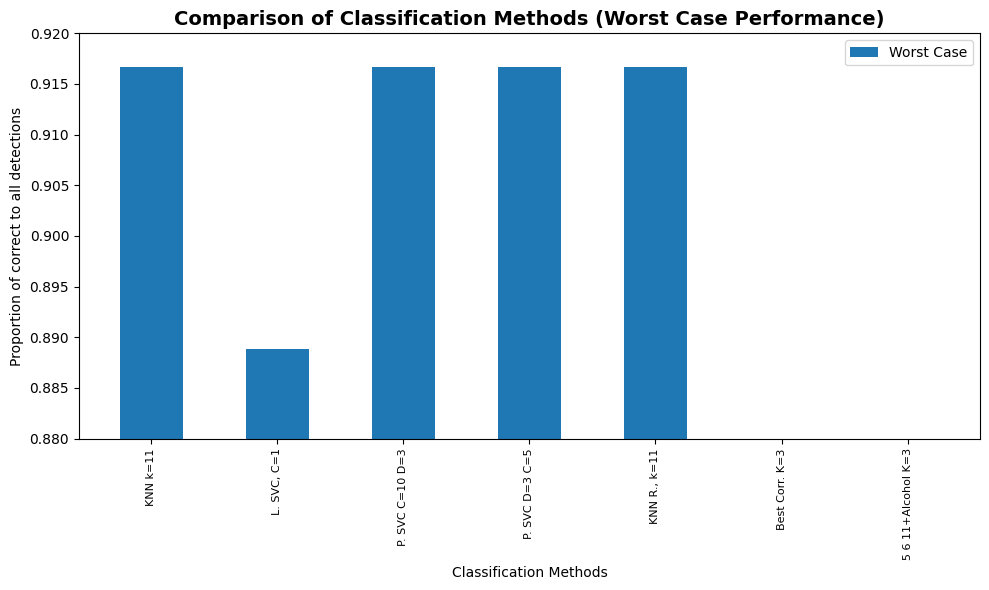

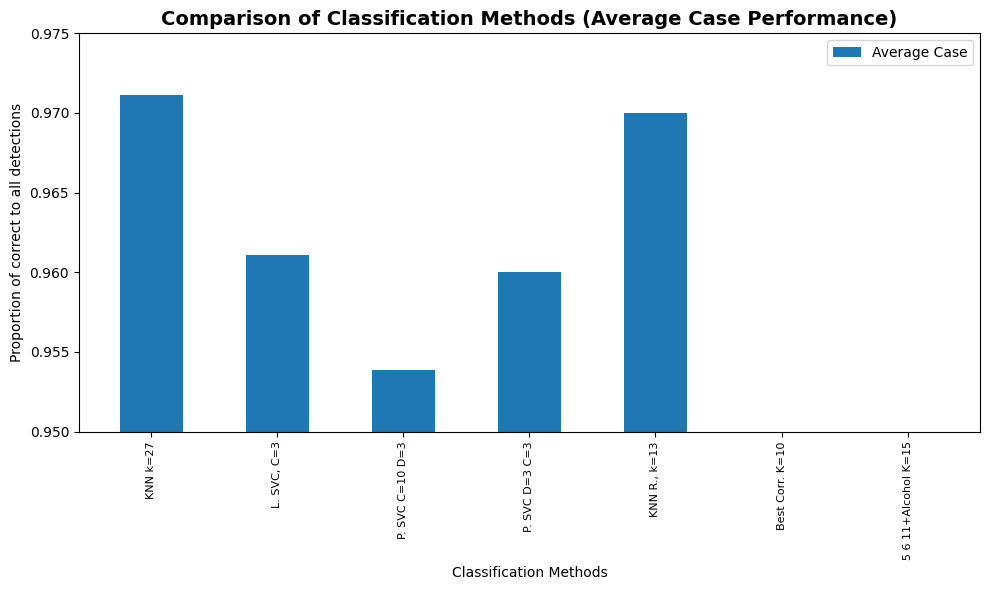

In [10]:
print("Result of each method in worst case:")
for item in bestResultsMin:
    item.printResult()
    print()

# Draw plot for worst cases
xPlot = np.arange(len(bestResultsMin))
width = 0.5

plt.figure(figsize=(10, 6))
plt.bar(xPlot        , [r.successProportionMin for r in bestResultsMin], width, label="Worst Case")
plt.ylim(0.88, 0.92)
plt.xticks(xPlot, [r.method for r in bestResultsMin], rotation=90, fontsize=8)
plt.xlabel("Classification Methods", fontsize = 10)
plt.ylabel("Proportion of correct to all detections", fontsize = 10)
plt.title("Comparison of Classification Methods (Worst Case Performance)", fontsize = 14, fontweight='bold')
plt.legend(loc='upper right')
plt.tight_layout()
plt.savefig('comparison_worst.png')

print("\n\n")

print("Result of each method in average case:")
for item in bestResultsAvg:
    item.printResult()
    print()

# Draw plot for average cases
xPlot = np.arange(len(bestResultsMin))
width = 0.5

plt.figure(figsize=(10, 6))
plt.bar(xPlot        , [r.successProportionAvg for r in bestResultsAvg], width, label="Average Case")
plt.ylim(0.95, 0.975)
plt.xticks(xPlot, [r.method for r in bestResultsAvg], rotation=90, fontsize=8)
plt.xlabel("Classification Methods", fontsize = 10)
plt.ylabel("Proportion of correct to all detections", fontsize = 10)
plt.title("Comparison of Classification Methods (Average Case Performance)", fontsize = 14, fontweight='bold')
plt.legend(loc='upper right')
plt.tight_layout()
plt.savefig('comparison_avg.png')

The goal of this project was to design a classification model for wine classification. I implemented KNN, Linear SVC, Polynomial SVC, and KNN Regression. In addition, in the hope of getting better results, I performed correlation analysis among all columns, tested KNN Regression on just the most correlated features, and then added the Alcohol column to those features and repeated the process.

I think all the methods gave solid results when I used all columns. All of them could correctly classify every test item when the right combination of training and test data came up, and even in the worst splits they still got about 90% right. I think if I had a larger dataset, the results would have been even better and more consistent. That said, to make a fair judgment, I think looking at the worst case and average results is what matters most. Although all methods worked well, my priority for choosing a classification method would be:

1. KNN Regression
2. KNN
3. Linear SVC (C >= 2)
4. Polynomial SVC (Degree = 3, C >= 3)

I need to mention that removing some columns did not satisfy me; even adding alcohol to the data still produced weaker results.